In [61]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import OrderedDict

In [62]:
################################################################################
# PINN for the 2D Wave Equation (First-order System Form)
#
# PDE System:
#   du/dt = v
#   dv/dt = c^2 * (u_xx + u_yy)
# Domain:
#   t in [0, T], x in [0, Lx], y in [0, Ly]
# Initial Conditions:
#   u(0, x, y)  = f1(x, y) = sin(pi*x) * sin(pi*y)
#   v(0, x, y)  = f2(x, y) = 0  (since ut(0, x, y) = 0)
# Boundary Conditions:
#   u(t, 0, y) = u(t, Lx, y) = u(t, x, 0) = u(t, x, Ly) = 0
#   v(t, 0, y) = v(t, Lx, y) = v(t, x, 0) = v(t, x, Ly) = 0
#
################################################################################

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [63]:
################################################################################
# Hyperparameters / Problem Setup
################################################################################
Lx = 1.0     # Spatial domain: x in [0, Lx]
Ly = 1.0     # Spatial domain: y in [0, Ly]
T = 1.0      # Temporal domain: t in [0, T]
c = 1.0      # Wave speed

n_collocation = 5000  # Number of collocation points inside domain
n_boundary    = 500   # Number of points for boundary conditions (each boundary)
n_initial     = 1000  # Number of points for initial conditions
hidden_layers = 6     # Number of hidden layers
neurons       = 50    # Neurons per hidden layer
learning_rate = 1e-3  # Learning rate for optimizer
num_epochs    = 10000 # Training epochs

In [64]:
################################################################################
# 2D MMPDE Sampling Class for 2D Wave Equation
################################################################################
# DNN class for MMPDE
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

################################################################################
# 修复后的2D MMPDE采样类
################################################################################
class sampling_MMPDE_2D():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        # 边界条件 [t_min, x_min, y_min], [t_max, x_max, y_max]
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        # 数据 - 输入格式: [t, x, y]
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.y_f = torch.tensor(X_f[:, 2:3], requires_grad=True).float().to(device)
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        # 深度神经网络 - 输入(t,x,y)，输出新的(x,y)坐标
        self.dnn = DNN(layers).to(device)

        # 优化器设置
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, t, x, y):
        """
        修复后的2D波动方程监测函数
        直接使用传入的t,x,y计算解和监测权重
        """
        # 确保输入张量都需要梯度
        t.requires_grad_(True)
        x.requires_grad_(True) 
        y.requires_grad_(True)
        
        # 使用当前的t,x,y计算解
        inputs = torch.cat([t, x, y], dim=1)
        uv = self.fun(inputs)
        u = uv[:, [0]]  # 位移u
        v = uv[:, [1]]  # 速度v = u_t

        # 计算u的空间梯度 - 分别对x和y求导
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]
        
        u_y = torch.autograd.grad(
            u, y,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        # 计算v的时间导数 (v_t = u_tt)
        v_t = torch.autograd.grad(
            v, t,
            grad_outputs=torch.ones_like(v),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        # 处理可能为None的梯度
        if u_x is None:
            u_x = torch.zeros_like(u)
        if u_y is None:
            u_y = torch.zeros_like(u)
        if v_t is None:
            v_t = torch.zeros_like(v)

        # 监测函数：结合空间梯度和时间二阶导数
        w = (1 + (u_x)**2 + (u_y)**2 + 0.1 * (v_t)**2) ** (1/2)
        
        return w

    def net_sample(self, t, x, y):
        """
        生成新的采样点 - 对x和y坐标进行自适应调整
        """
        inputs = torch.cat([t, x, y], dim=1)
        xy_new = self.dnn(inputs)
        
        # 分离x和y的新坐标
        x_new = xy_new[:, [0]]
        y_new = xy_new[:, [1]]
        
        # 应用边界条件约束
        gx0 = x - self.lb[1]  # x - x_min
        gx1 = x - self.ub[1]  # x - x_max
        gy0 = y - self.lb[2]  # y - y_min  
        gy1 = y - self.ub[2]  # y - y_max
        
        # 确保新坐标在边界处为原坐标
        x_new = gx0 * gx1 * x_new + x
        y_new = gy0 * gy1 * y_new + y
        
        return x_new, y_new

    def net_f(self, t, x, y):
        """
        计算2D MMPDE方程的残差
        """
        x_new, y_new = self.net_sample(t, x, y)

        # 计算新坐标的时间导数
        x_new_t = torch.autograd.grad(
            x_new, t,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_t = torch.autograd.grad(
            y_new, t,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算新坐标的空间导数
        x_new_x = torch.autograd.grad(
            x_new, x,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_y = torch.autograd.grad(
            x_new, y,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_x = torch.autograd.grad(
            y_new, x,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_y = torch.autograd.grad(
            y_new, y,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算新坐标的二阶导数
        x_new_xx = torch.autograd.grad(
            x_new_x, x,
            grad_outputs=torch.ones_like(x_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_yy = torch.autograd.grad(
            x_new_y, y,
            grad_outputs=torch.ones_like(x_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_xx = torch.autograd.grad(
            y_new_x, x,
            grad_outputs=torch.ones_like(y_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_yy = torch.autograd.grad(
            y_new_y, y,
            grad_outputs=torch.ones_like(y_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算监测函数 - 使用修复后的monitor函数
        G = self.monitor(t, x, y)

        # 计算监测函数的导数
        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_y = torch.autograd.grad(
            G, y,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 2D MMPDE方程的残差
        # For x coordinate:
        E_x = G_x * x_new_x + G_y * x_new_y + G * (x_new_xx + x_new_yy)
        f_x = x_new_t * self.nu * (G**2) * (x_new_x**2 + x_new_y**2) + E_x

        # For y coordinate:
        E_y = G_x * y_new_x + G_y * y_new_y + G * (y_new_xx + y_new_yy)
        f_y = y_new_t * self.nu * (G**2) * (y_new_x**2 + y_new_y**2) + E_y

        return f_x, f_y

    def loss_func(self):
        """计算损失函数"""
        f_x, f_y = self.net_f(self.t_f, self.x_f, self.y_f)
        loss_f = torch.mean(f_x ** 2) + torch.mean(f_y ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        # 损失函数初始化
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        """训练过程"""
        print("开始2D MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("2D MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('2D MMPDE_LBGFS 完成!')

        # 返回新的采样点
        x_new, y_new = self.net_sample(self.t_f, self.x_f, self.y_f)
        new_sample = torch.cat([self.t_f, x_new, y_new], dim=1)
        return new_sample


def create_2d_simulation_function(model=None):
    """创建2D波动方程的模拟函数"""
    if model is None:
        # 使用解析解
        def simulation_function(txy):
            t, x, y = txy[:, 0:1], txy[:, 1:2], txy[:, 2:3]
            u = torch.sin(torch.pi * x) * torch.sin(torch.pi * y) * torch.cos(torch.sqrt(torch.tensor(2.0)) * torch.pi * t)
            v = -torch.sqrt(torch.tensor(2.0)) * torch.pi * torch.sin(torch.pi * x) * torch.sin(torch.pi * y) * torch.sin(torch.sqrt(torch.tensor(2.0)) * torch.pi * t)
            return torch.cat([u, v], dim=1)
    else:
        # 使用训练好的模型
        def simulation_function(txy):
            with torch.no_grad():
                return model(txy)
    
    return simulation_function

In [65]:
################################################################################
# Neural Network Definition
################################################################################
class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        self.activation = activation
        
        # Initialize weights (Xavier initialization)
        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Forward pass
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))
        # output: [u, v] where v = u_t
        x = self.linears[-1](x)
        return x

In [66]:
################################################################################
# Define the true initial conditions f1(x,y), f2(x,y), and boundary conditions
################################################################################
def f1(x, y):
    # initial displacement: sin(pi*x) * sin(pi*y)
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def f2(x, y):
    # initial velocity: zero
    return np.zeros_like(x)

def boundary_condition_u(t, x, y):
    # Dirichlet boundary conditions for u (all edges)
    return np.zeros_like(t)

def boundary_condition_v(t, x, y):
    # Dirichlet boundary conditions for v (all edges)
    return np.zeros_like(t)

In [67]:
################################################################################
# Exact Solution for the 2D Wave Equation (if available)
################################################################################
def exact_solution_u(x, y, t, c=1.0):
    """
    Exact analytical solution for u: u(x,y,t) = sin(πx) * sin(πy) * cos(c*sqrt(2)*πt)
    """
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.cos(omega * t)

def exact_solution_v(x, y, t, c=1.0):
    """
    Exact analytical solution for v: v(x,y,t) = du/dt = -c*sqrt(2)*π * sin(πx) * sin(πy) * sin(c*sqrt(2)*πt)
    """
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return -omega * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(omega * t)

def exact_solution_uv(x, y, t, c=1.0):
    """
    Return both u and v as a combined solution
    """
    u = exact_solution_u(x, y, t, c)
    v = exact_solution_v(x, y, t, c)
    return np.column_stack((u.flatten(), v.flatten()))


In [68]:
################################################################################
# 2D MMPDE Adaptive Sampling Implementation
################################################################################

# 参数设置
nu = 0.1  # MMPDE参数

# 定义2D域边界
lb = [0.0, 0.0, 0.0]  # [t_min, x_min, y_min]
ub = [T, Lx, Ly]      # [t_max, x_max, y_max]

# 生成初始均匀分布的采样点
def generate_initial_samples_2d(n_samples=2000):
    """生成2D域的初始采样点"""
    # 立方体根来确定每个维度的采样点数
    n_per_dim = int(np.cbrt(n_samples))
    
    t_uniform = torch.linspace(0, T, n_per_dim)
    x_uniform = torch.linspace(0, Lx, n_per_dim)  
    y_uniform = torch.linspace(0, Ly, n_per_dim)
    
    # 创建3D网格
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    t_init = T_grid.reshape(-1, 1)
    x_init = X_grid.reshape(-1, 1)
    y_init = Y_grid.reshape(-1, 1)
    
    # 合并为输入样本 [t, x, y]
    X_f_init = torch.cat([t_init, x_init, y_init], dim=1).numpy()
    
    return X_f_init

# 生成初始采样点
X_f_init = generate_initial_samples_2d(n_samples=5000)
# 创建2D模拟函数
sim_func_2d = create_2d_simulation_function()

# 定义2D MMPDE参数
mmpde_layers_2d = [3, 40, 40, 40, 2]  # 输入(t,x,y)，输出新的(x,y)坐标
adam_iter = 1000
lbfgs_iter = 300

print(f"初始采样点数量: {X_f_init.shape[0]}")
print(f"使用设备: {device}")

# 创建2D MMPDE采样器并训练
mmpde_sampler_2d = sampling_MMPDE_2D(
    X_f=X_f_init,
    u_fun=sim_func_2d,
    layers=mmpde_layers_2d,
    lb=lb,
    ub=ub,
    nu=nu,
    AdamIter=adam_iter,
    LBFGSIter=lbfgs_iter
)

# 训练MMPDE并获取优化后的采样点
print("开始训练2D MMPDE采样器...")
new_samples_2d = mmpde_sampler_2d.train()
print("2D MMPDE训练完成!")

# 提取优化后的采样点
t_colloc_adaptive = new_samples_2d[:, 0:1].clone().detach().requires_grad_(True)
x_colloc_adaptive = new_samples_2d[:, 1:2].clone().detach().requires_grad_(True)  
y_colloc_adaptive = new_samples_2d[:, 2:3].clone().detach().requires_grad_(True)

print(f"自适应采样点数量: {new_samples_2d.shape[0]}")

初始采样点数量: 4913
使用设备: cuda
开始训练2D MMPDE采样器...
开始2D MMPDE训练...
2D_MMPDE_Adam Iter 100, Loss: 8.187307
Time: 6.2939s
2D_MMPDE_Adam Iter 200, Loss: 6.786469
Time: 6.1120s
2D_MMPDE_Adam Iter 300, Loss: 5.892535
Time: 5.9786s
2D_MMPDE_Adam Iter 400, Loss: 5.579533
Time: 6.0691s
2D_MMPDE_Adam Iter 500, Loss: 3.140162
Time: 6.0740s
2D_MMPDE_Adam Iter 600, Loss: 1.854165
Time: 6.1399s
2D_MMPDE_Adam Iter 700, Loss: 1.638418
Time: 6.2725s
2D_MMPDE_Adam Iter 800, Loss: 1.555036
Time: 6.1816s
2D_MMPDE_Adam Iter 900, Loss: 1.505174
Time: 5.9609s
2D_MMPDE_Adam Iter 1000, Loss: 1.471344
Time: 6.1861s
2D MMPDE_Adam 完成!
2D_MMPDE_LBFGS Iter 1100, Loss: 1.377088
Time: 7.3741s
2D_MMPDE_LBFGS Iter 1200, Loss: 1.338994
Time: 9.4431s
2D_MMPDE_LBFGS Iter 1300, Loss: 1.314956
Time: 9.4621s
2D MMPDE_LBGFS 完成!
2D MMPDE训练完成!
自适应采样点数量: 4913


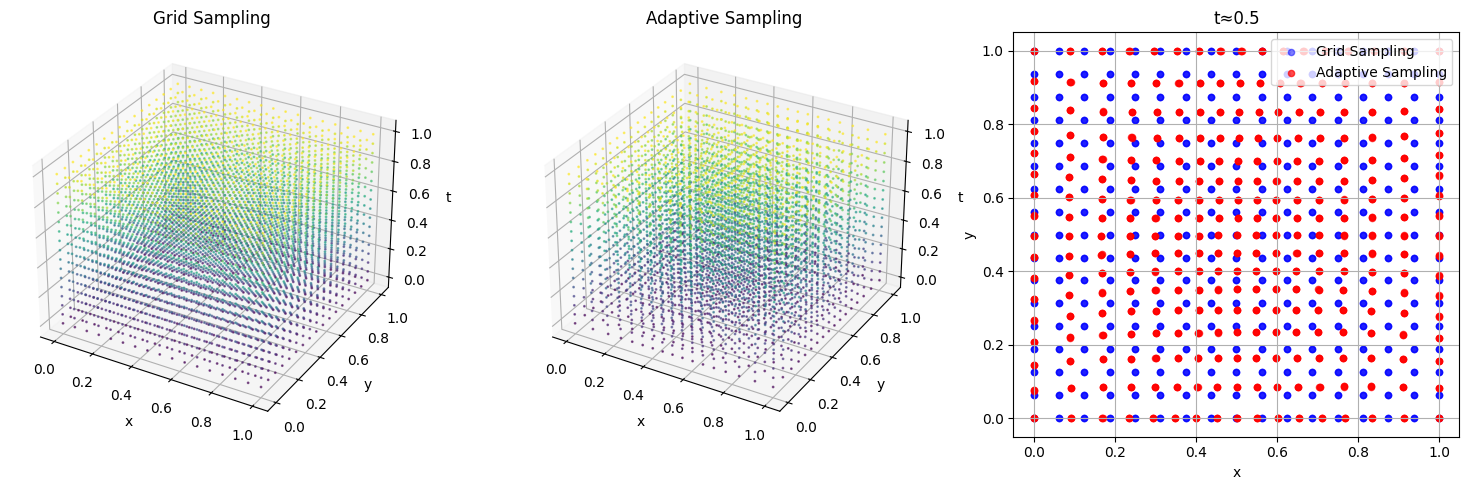

In [69]:
################################################################################
# Adaptive Sampling Visualization
################################################################################
def visualize_adaptive_sampling(original_samples, adaptive_samples):
    """可视化自适应采样点的分布"""
    fig = plt.figure(figsize=(15, 5))
    
    # 原始均匀采样
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(original_samples[:, 1], original_samples[:, 2], original_samples[:, 0], 
               c=original_samples[:, 0], cmap='viridis', alpha=0.6, s=1)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y') 
    ax1.set_zlabel('t')
    ax1.set_title('Grid Sampling')
    
    # 自适应采样
    ax2 = fig.add_subplot(132, projection='3d')
    adaptive_np = adaptive_samples.detach().cpu().numpy()
    ax2.scatter(adaptive_np[:, 1], adaptive_np[:, 2], adaptive_np[:, 0],
               c=adaptive_np[:, 0], cmap='viridis', alpha=0.6, s=1)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('t')
    ax2.set_title('Adaptive Sampling')
    
    # 在t=0.5时刻的xy平面投影对比
    ax3 = fig.add_subplot(133)
    
    # 找到接近t=0.5的点
    t_target = 0.5
    tol = 0.1
    
    # 原始采样
    mask_orig = np.abs(original_samples[:, 0] - t_target) < tol
    if np.any(mask_orig):
        ax3.scatter(original_samples[mask_orig, 1], original_samples[mask_orig, 2], 
                   alpha=0.5, label='Grid Sampling', s=20, c='blue')
    
    # 自适应采样
    mask_adapt = torch.abs(adaptive_samples[:, 0] - t_target) < tol
    if torch.any(mask_adapt):
        adaptive_subset = adaptive_samples[mask_adapt].detach().cpu().numpy()
        ax3.scatter(adaptive_subset[:, 1], adaptive_subset[:, 2], 
                   alpha=0.7, label='Adaptive Sampling', s=20, c='red')
    
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    ax3.set_title(f't≈{t_target}')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

# 可视化采样点分布
visualize_adaptive_sampling(X_f_init, new_samples_2d)

In [70]:
################################################################################
# Modified Training Data Generation with Adaptive Sampling
################################################################################
def generate_training_data_adaptive():
    """使用自适应采样点生成训练数据"""
    
    # 使用自适应采样的配点
    collocation_pts = (t_colloc_adaptive, x_colloc_adaptive, y_colloc_adaptive)
    
    # 初始条件点保持不变
    grid_size = int(np.sqrt(n_initial))
    x_init_grid, y_init_grid = np.meshgrid(np.linspace(0, Lx, grid_size), 
                                          np.linspace(0, Ly, grid_size))
    x_init = x_init_grid.flatten().reshape(-1, 1)
    y_init = y_init_grid.flatten().reshape(-1, 1)
    t_init = np.zeros_like(x_init)
    
    # 初始条件值
    u_init = f1(x_init, y_init)
    v_init = f2(x_init, y_init)
    uv_init = np.column_stack((u_init.flatten(), v_init.flatten()))
    
    # 转换为张量
    t_init = torch.tensor(t_init, dtype=torch.float32, device=device, requires_grad=True)
    x_init = torch.tensor(x_init, dtype=torch.float32, device=device, requires_grad=True)
    y_init = torch.tensor(y_init, dtype=torch.float32, device=device, requires_grad=True)
    uv_init = torch.tensor(uv_init, dtype=torch.float32, device=device)
    
    # 边界条件点保持不变
    # Bottom boundary (y=0)
    t_bound_bottom = torch.rand(n_boundary, 1, device=device) * T
    x_bound_bottom = torch.rand(n_boundary, 1, device=device) * Lx
    y_bound_bottom = torch.zeros(n_boundary, 1, device=device)
    
    # Top boundary (y=Ly)
    t_bound_top = torch.rand(n_boundary, 1, device=device) * T
    x_bound_top = torch.rand(n_boundary, 1, device=device) * Lx
    y_bound_top = Ly * torch.ones(n_boundary, 1, device=device)
    
    # Left boundary (x=0)
    t_bound_left = torch.rand(n_boundary, 1, device=device) * T
    x_bound_left = torch.zeros(n_boundary, 1, device=device)
    y_bound_left = torch.rand(n_boundary, 1, device=device) * Ly
    
    # Right boundary (x=Lx)
    t_bound_right = torch.rand(n_boundary, 1, device=device) * T
    x_bound_right = Lx * torch.ones(n_boundary, 1, device=device)
    y_bound_right = torch.rand(n_boundary, 1, device=device) * Ly
    
    # 边界条件值（均为0）
    uv_bound_bottom = torch.zeros(n_boundary, 2, device=device)
    uv_bound_top = torch.zeros(n_boundary, 2, device=device)
    uv_bound_left = torch.zeros(n_boundary, 2, device=device)
    uv_bound_right = torch.zeros(n_boundary, 2, device=device)
    
    # 设置梯度计算
    t_bound_bottom.requires_grad_(True)
    x_bound_bottom.requires_grad_(True)
    y_bound_bottom.requires_grad_(True)
    t_bound_top.requires_grad_(True)
    x_bound_top.requires_grad_(True)
    y_bound_top.requires_grad_(True)
    t_bound_left.requires_grad_(True)
    x_bound_left.requires_grad_(True)
    y_bound_left.requires_grad_(True)
    t_bound_right.requires_grad_(True)
    x_bound_right.requires_grad_(True)
    y_bound_right.requires_grad_(True)

    # 打包数据
    initial_pts = (t_init, x_init, y_init, uv_init)
    boundary_pts = {
        'bottom': (t_bound_bottom, x_bound_bottom, y_bound_bottom, uv_bound_bottom),
        'top': (t_bound_top, x_bound_top, y_bound_top, uv_bound_top),
        'left': (t_bound_left, x_bound_left, y_bound_left, uv_bound_left),
        'right': (t_bound_right, x_bound_right, y_bound_right, uv_bound_right)
    }

    return collocation_pts, initial_pts, boundary_pts

# 生成使用自适应采样的训练数据
collocation_pts_adaptive, initial_pts_adaptive, boundary_pts_adaptive = generate_training_data_adaptive()

print("自适应采样训练数据生成完成!")
print(f"配点数量: {len(t_colloc_adaptive)}")
print(f"初始条件点数量: {len(initial_pts_adaptive[0])}")
print(f"边界条件点数量: {len(boundary_pts_adaptive['bottom'][0]) * 4}")

自适应采样训练数据生成完成!
配点数量: 4913
初始条件点数量: 961
边界条件点数量: 2000


In [71]:
################################################################################
# Physics-Informed Loss Function (First-order System Form)
################################################################################
def wave_pde_loss(model, t, x, y):
    """
    Compute PDE residual for the first-order system:
    du/dt = v
    dv/dt = c^2 * (u_xx + u_yy)
    """
    # Ensure gradients are computed
    t.requires_grad_(True)
    x.requires_grad_(True)
    y.requires_grad_(True)

    # NN output: [u, v]
    inputs = torch.cat((t, x, y), dim=1)
    uv = model(inputs)
    u = uv[:, [0]]  # u component
    v = uv[:, [1]]  # v component (should be u_t)

    # First derivatives of u
    u_grads = torch.autograd.grad(u, inputs, 
                                 grad_outputs=torch.ones_like(u), 
                                 create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]

    # First derivatives of v
    v_grads = torch.autograd.grad(v, inputs,
                                 grad_outputs=torch.ones_like(v),
                                 create_graph=True)[0]
    v_t = v_grads[:, [0]]

    # Second spatial derivatives of u
    u_xx = torch.autograd.grad(u_x, x,
                              grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y,
                              grad_outputs=torch.ones_like(u_y),
                              create_graph=True)[0]

    # PDE residuals for the first-order system:
    # Equation 1: du/dt = v
    f_u = u_t - v
    
    # Equation 2: dv/dt = c^2 * (u_xx + u_yy)
    f_v = v_t - (c**2) * (u_xx + u_yy)

    return torch.mean(f_u**2) + torch.mean(f_v**2)


def initial_condition_loss(model, t, x, y, uv_true):
    """
    Compute loss for initial conditions: u(0,x,y) = f1(x,y) and v(0,x,y) = f2(x,y)
    """
    inputs = torch.cat((t, x, y), dim=1)
    uv_pred = model(inputs)
    ic_loss = torch.mean((uv_pred - uv_true)**2)
    
    return ic_loss


def boundary_condition_loss(model, boundary_pts):
    """
    Compute loss for boundary conditions at all four edges of the domain.
    """
    bc_loss = 0
    
    # Process each boundary
    for boundary_name, (t, x, y, uv_true) in boundary_pts.items():
        inputs = torch.cat((t, x, y), dim=1)
        uv_pred = model(inputs)
        bc_loss += torch.mean((uv_pred - uv_true)**2)
    
    return bc_loss


def loss_function(model, collocation_pts, initial_pts, boundary_pts):
    """
    Compute total loss for the PINN.
    """
    # Unpack data
    t_coll, x_coll, y_coll = collocation_pts
    t_init, x_init, y_init, uv_init = initial_pts
    
    # PDE residual loss
    pde_loss = wave_pde_loss(model, t_coll, x_coll, y_coll)
    
    # Initial condition loss
    ic_loss = initial_condition_loss(model, t_init, x_init, y_init, uv_init)
    
    # Boundary condition loss
    bc_loss = boundary_condition_loss(model, boundary_pts)
    
    # Combine losses with appropriate weights
    total_loss = pde_loss + ic_loss + bc_loss
    
    return total_loss, pde_loss, ic_loss, bc_loss

In [72]:
################################################################################
# Visualization Functions
################################################################################
def visualize_solution(model, time_slices=[0.25, 0.5, 0.75, 1.0], save_path=None):
    """
    Plot the PINN solution at several time points and compare with exact solution.
    """
    fig = plt.figure(figsize=(20, 15))
    x_grid = np.linspace(0, Lx, 50)
    y_grid = np.linspace(0, Ly, 50)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    for i, t_val in enumerate(time_slices):
        # Prepare input tensors 
        t_tensor = torch.full((X.size,1), t_val, dtype=torch.float32, device=device)
        x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        
        # Predict using PINN
        with torch.no_grad():
            inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
            uv_pred = model(inputs).cpu().numpy()
            u_pred = uv_pred[:, 0].reshape(X.shape)
            v_pred = uv_pred[:, 1].reshape(X.shape)
        
        # Compute exact solution
        u_exact = exact_solution_u(X, Y, t_val)
        v_exact = exact_solution_v(X, Y, t_val)
        
        # Plot u component
        ax1 = fig.add_subplot(len(time_slices), 6, 6*i+1, projection='3d')
        surf1 = ax1.plot_surface(X, Y, u_pred, cmap=cm.coolwarm)
        ax1.set_title(f'PINN u at t={t_val}')
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        ax1.set_zlabel('u')
        fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
        
        ax2 = fig.add_subplot(len(time_slices), 6, 6*i+2, projection='3d')
        surf2 = ax2.plot_surface(X, Y, u_exact, cmap=cm.coolwarm)
        ax2.set_title(f'Exact u at t={t_val}')
        ax2.set_xlabel('x')
        ax2.set_ylabel('y')
        ax2.set_zlabel('u')
        fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
        
        ax3 = fig.add_subplot(len(time_slices), 6, 6*i+3, projection='3d')
        error_u = np.abs(u_pred - u_exact)
        surf3 = ax3.plot_surface(X, Y, error_u, cmap=cm.Reds)
        ax3.set_title(f'|u error| at t={t_val}')
        ax3.set_xlabel('x')
        ax3.set_ylabel('y')
        ax3.set_zlabel('|error|')
        fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=5)
        
        # Plot v component
        ax4 = fig.add_subplot(len(time_slices), 6, 6*i+4, projection='3d')
        surf4 = ax4.plot_surface(X, Y, v_pred, cmap=cm.coolwarm)
        ax4.set_title(f'PINN v at t={t_val}')
        ax4.set_xlabel('x')
        ax4.set_ylabel('y')
        ax4.set_zlabel('v')
        fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=5)
        
        ax5 = fig.add_subplot(len(time_slices), 6, 6*i+5, projection='3d')
        surf5 = ax5.plot_surface(X, Y, v_exact, cmap=cm.coolwarm)
        ax5.set_title(f'Exact v at t={t_val}')
        ax5.set_xlabel('x')
        ax5.set_ylabel('y')
        ax5.set_zlabel('v')
        fig.colorbar(surf5, ax=ax5, shrink=0.5, aspect=5)
        
        ax6 = fig.add_subplot(len(time_slices), 6, 6*i+6, projection='3d')
        error_v = np.abs(v_pred - v_exact)
        surf6 = ax6.plot_surface(X, Y, error_v, cmap=cm.Reds)
        ax6.set_title(f'|v error| at t={t_val}')
        ax6.set_xlabel('x')
        ax6.set_ylabel('y')
        ax6.set_zlabel('|error|')
        fig.colorbar(surf6, ax=ax6, shrink=0.5, aspect=5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

In [73]:
################################################################################
# Training Setup and Execution
################################################################################
# Generate training data
collocation_pts, initial_pts, boundary_pts = generate_training_data_adaptive()

# Create model (now outputs 2 components: [u, v])
layers = [3] + [neurons]*hidden_layers + [2]  # 3 inputs: (t, x, y), 2 outputs: [u, v]
model = PINN(layers, activation=nn.Tanh()).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1000)

# Training history
loss_history = []
pde_loss_history = []
ic_loss_history = []
bc_loss_history = []

print("Starting training...")
# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Compute loss
    loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
    
    # Store loss values
    loss_history.append(loss.item())
    pde_loss_history.append(pde_loss.item())
    ic_loss_history.append(ic_loss.item())
    bc_loss_history.append(bc_loss.item())
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    # Update learning rate
    scheduler.step(loss)
    
    # Print progress
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Loss: {loss.item():.6e}, "
              f"PDE Loss: {pde_loss.item():.6e}, "
              f"IC Loss: {ic_loss.item():.6e}, "
              f"BC Loss: {bc_loss.item():.6e}")

print("Training completed!")

Starting training...
Epoch [500/10000], Loss: 9.204762e-02, PDE Loss: 4.147215e-03, IC Loss: 7.651315e-02, BC Loss: 1.138726e-02
Epoch [1000/10000], Loss: 8.965564e-02, PDE Loss: 2.983629e-03, IC Loss: 6.951282e-02, BC Loss: 1.715919e-02
Epoch [1500/10000], Loss: 7.446360e-02, PDE Loss: 8.036947e-03, IC Loss: 5.379466e-02, BC Loss: 1.263199e-02
Epoch [2000/10000], Loss: 5.795414e-02, PDE Loss: 9.149134e-03, IC Loss: 3.735091e-02, BC Loss: 1.145409e-02
Epoch [2500/10000], Loss: 6.245576e-02, PDE Loss: 2.429785e-02, IC Loss: 2.564453e-02, BC Loss: 1.251338e-02
Epoch [3000/10000], Loss: 3.814635e-02, PDE Loss: 9.140768e-03, IC Loss: 1.921050e-02, BC Loss: 9.795086e-03
Epoch [3500/10000], Loss: 3.268012e-02, PDE Loss: 9.047896e-03, IC Loss: 1.445315e-02, BC Loss: 9.179067e-03
Epoch [4000/10000], Loss: 2.859899e-02, PDE Loss: 8.401168e-03, IC Loss: 1.183042e-02, BC Loss: 8.367399e-03
Epoch [4500/10000], Loss: 4.695152e-02, PDE Loss: 2.483362e-02, IC Loss: 9.728502e-03, BC Loss: 1.238940e-02

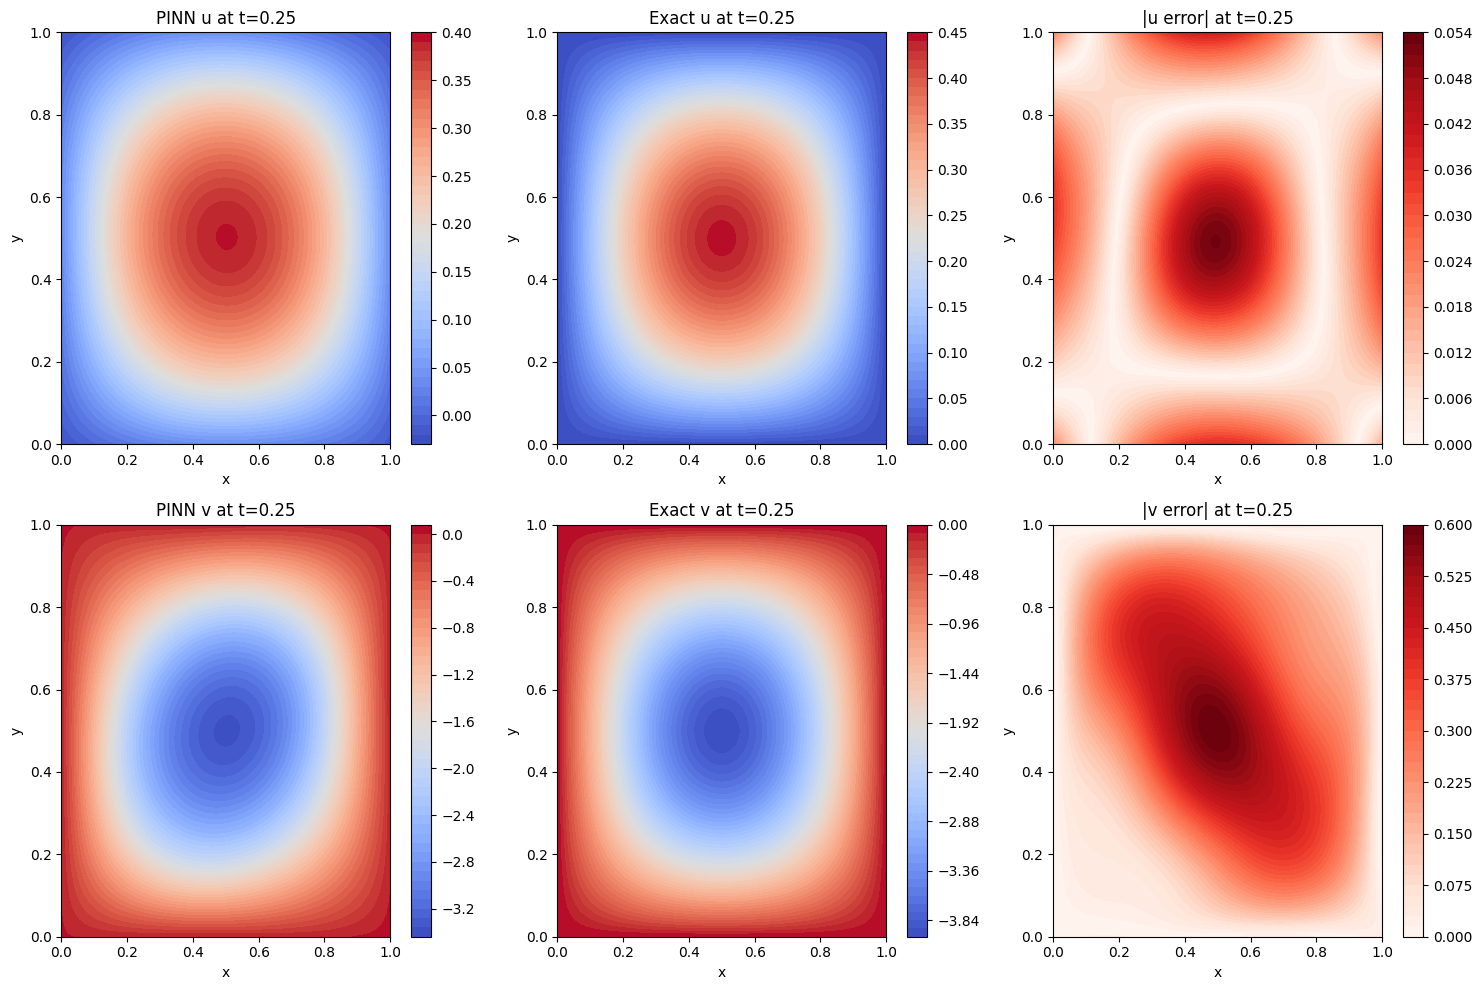

At t=0.25:
Max |u error|: 5.267003e-02
Mean |u error|: 1.550421e-02
Max |v error|: 5.983601e-01
Mean |v error|: 2.309079e-01


In [74]:
################################################################################
# Solution Visualization at t=0.25 (2D contour plots)
################################################################################
def visualize_solution_2d(model, t_val=0.25):
    """
    Plot 2D contour comparison at a specific time slice
    """
    # Create grid
    x_grid = np.linspace(0, Lx, 100)
    y_grid = np.linspace(0, Ly, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # Prepare input tensors
    t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
    x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    
    # Predict using PINN
    with torch.no_grad():
        inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
        uv_pred = model(inputs).cpu().numpy()
        u_pred = uv_pred[:, 0].reshape(X.shape)
        v_pred = uv_pred[:, 1].reshape(X.shape)
    
    # Compute exact solution
    u_exact = exact_solution_u(X, Y, t_val)
    v_exact = exact_solution_v(X, Y, t_val)
    
    # Compute errors
    error_u = np.abs(u_pred - u_exact)
    error_v = np.abs(v_pred - v_exact)
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # u component plots
    im1 = axes[0, 0].contourf(X, Y, u_pred, levels=50, cmap='coolwarm')
    axes[0, 0].set_title(f'PINN u at t={t_val}')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('y')
    plt.colorbar(im1, ax=axes[0, 0])
    
    im2 = axes[0, 1].contourf(X, Y, u_exact, levels=50, cmap='coolwarm')
    axes[0, 1].set_title(f'Exact u at t={t_val}')
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('y')
    plt.colorbar(im2, ax=axes[0, 1])
    
    im3 = axes[0, 2].contourf(X, Y, error_u, levels=50, cmap='Reds')
    axes[0, 2].set_title(f'|u error| at t={t_val}')
    axes[0, 2].set_xlabel('x')
    axes[0, 2].set_ylabel('y')
    plt.colorbar(im3, ax=axes[0, 2])
    
    # v component plots
    im4 = axes[1, 0].contourf(X, Y, v_pred, levels=50, cmap='coolwarm')
    axes[1, 0].set_title(f'PINN v at t={t_val}')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')
    plt.colorbar(im4, ax=axes[1, 0])
    
    im5 = axes[1, 1].contourf(X, Y, v_exact, levels=50, cmap='coolwarm')
    axes[1, 1].set_title(f'Exact v at t={t_val}')
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('y')
    plt.colorbar(im5, ax=axes[1, 1])
    
    im6 = axes[1, 2].contourf(X, Y, error_v, levels=50, cmap='Reds')
    axes[1, 2].set_title(f'|v error| at t={t_val}')
    axes[1, 2].set_xlabel('x')
    axes[1, 2].set_ylabel('y')
    plt.colorbar(im6, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.savefig(f"2d_wave_solution_t{t_val}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print error statistics
    print(f"At t={t_val}:")
    print(f"Max |u error|: {np.max(error_u):.6e}")
    print(f"Mean |u error|: {np.mean(error_u):.6e}")
    print(f"Max |v error|: {np.max(error_v):.6e}")
    print(f"Mean |v error|: {np.mean(error_v):.6e}")

# Visualize the solution at t=0.25
visualize_solution_2d(model, t_val=0.25)

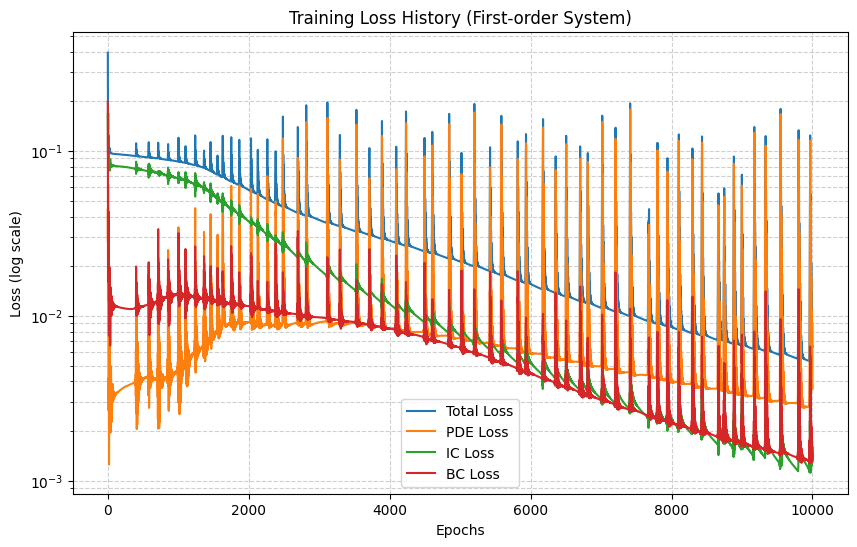

In [75]:
################################################################################
# Loss History Visualization
################################################################################
plt.figure(figsize=(10, 6))
plt.semilogy(loss_history, label='Total Loss')
plt.semilogy(pde_loss_history, label='PDE Loss')
plt.semilogy(ic_loss_history, label='IC Loss')
plt.semilogy(bc_loss_history, label='BC Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss History (First-order System)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.savefig("2d_wave_loss_history_system.png", dpi=300, bbox_inches='tight')
plt.show()